In [1]:
import sys
sys.path.append("..")

from src.clonality import run_clonality_analysis
from src.dataset_loader import load_dataset

import scanpy as sc
import matplotlib
from matplotlib import rcParams

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, dpi_save=300, color_map='Reds', facecolor='white')
matplotlib.rcParams.update({'figure.figsize': (6, 6)})


# adata_peri = load_dataset("perigas_bgi")
# adata_perigas_endo = load_dataset("perigas_endo")
# adata_hypo = load_dataset("embryotree_hypo")
# adata_embryo = load_dataset("embryotree")

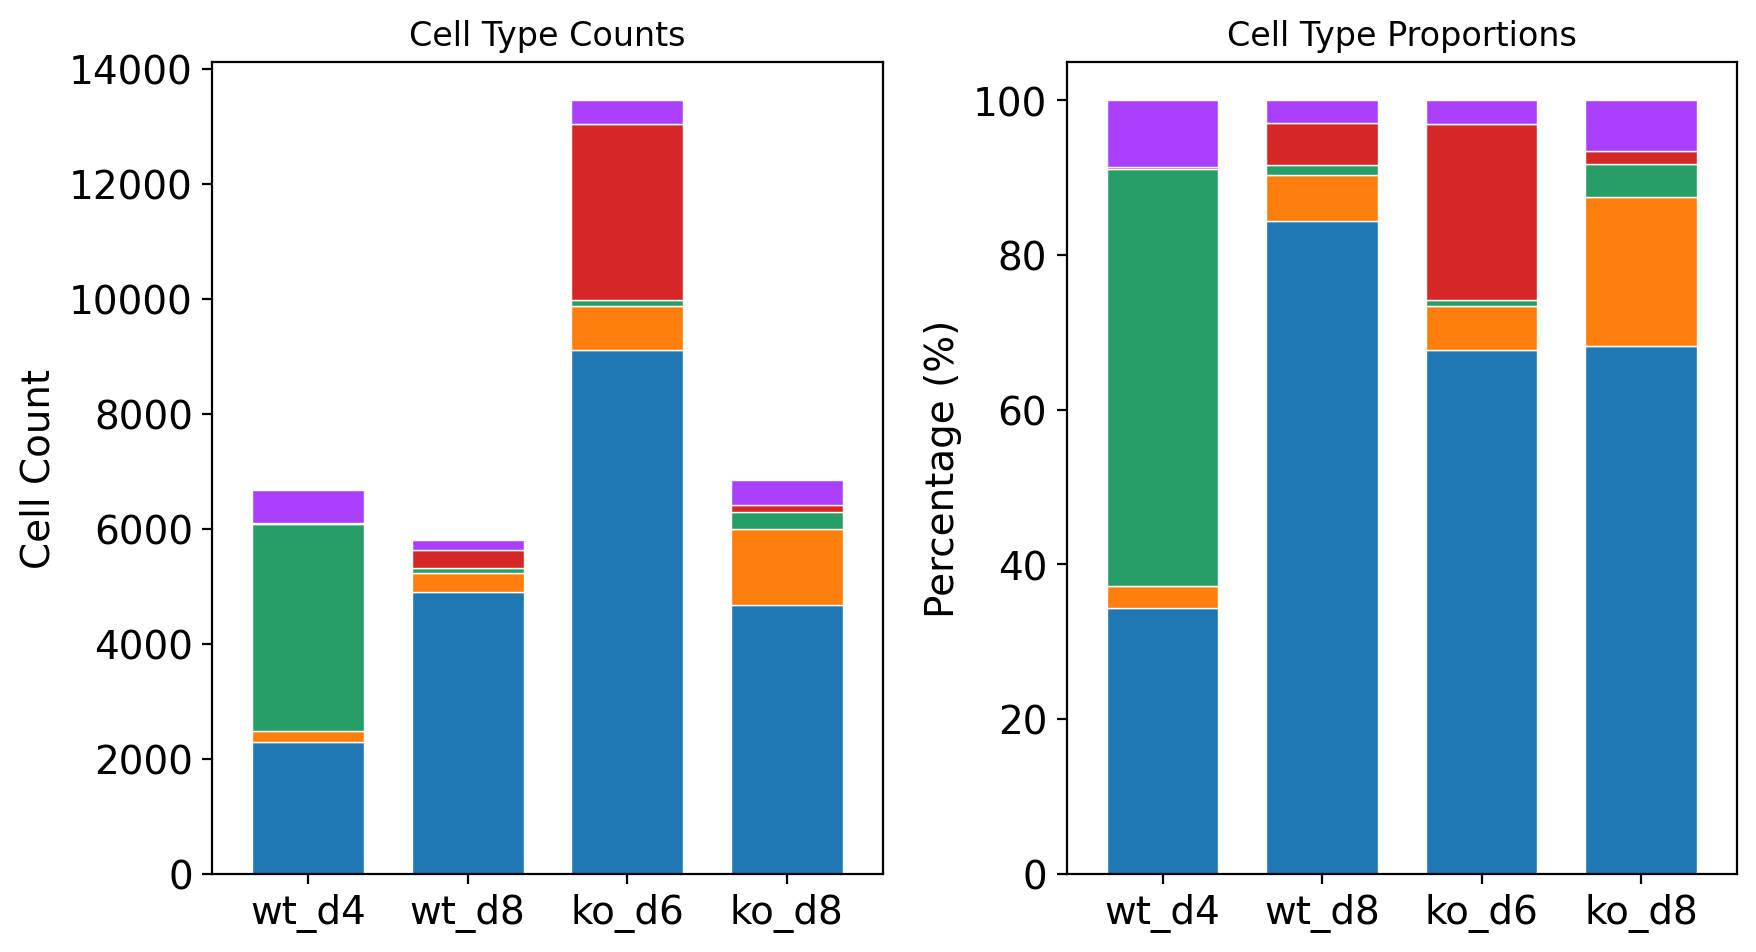

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

celltype_counts = pd.crosstab(adata.obs['sample'], adata.obs['CellType_man'])
celltype_counts = celltype_counts.reindex(['wt_d4', 'wt_d8', 'ko_d6', 'ko_d8'])
# celltype_counts.index = ['WT', 'CDX2-/-']

celltype_props = celltype_counts.div(celltype_counts.sum(axis=1), axis=0) * 100

colors = adata.uns['CellType_man_colors']

fig, axes = plt.subplots(1, 2, figsize=(9, 5), gridspec_kw={'width_ratios': [1, 1]})

celltype_counts.plot(kind='bar', stacked=True, ax=axes[0], 
                     color=colors, legend=False, width=0.7, edgecolor='white', linewidth=0.5)
axes[0].set_title('Cell Type Counts', fontsize=12)
axes[0].set_ylabel('Cell Count')

celltype_props.plot(kind='bar', stacked=True, ax=axes[1], 
                    color=colors, legend=False, width=0.7, edgecolor='white', linewidth=0.5)
axes[1].set_title('Cell Type Proportions', fontsize=12)
axes[1].set_ylabel('Percentage (%)')

for ax in axes:
    ax.grid(False)               
    ax.set_facecolor('none')     
    ax.set_xlabel('')            
    ax.tick_params(axis='x', rotation=0) 
    
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

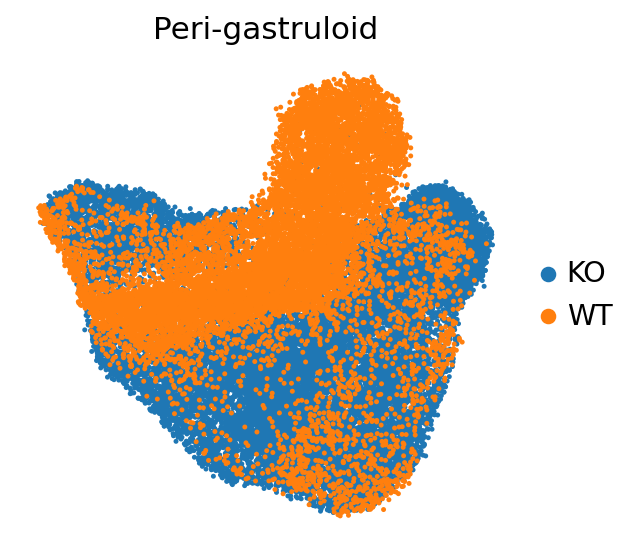

In [30]:
sc.pl.umap(adata, color='group', title='Peri-gastruloid', 
          frameon=False, size=20)

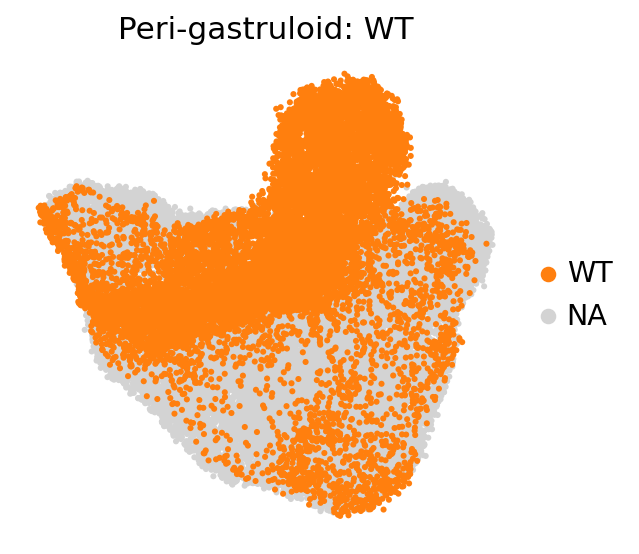

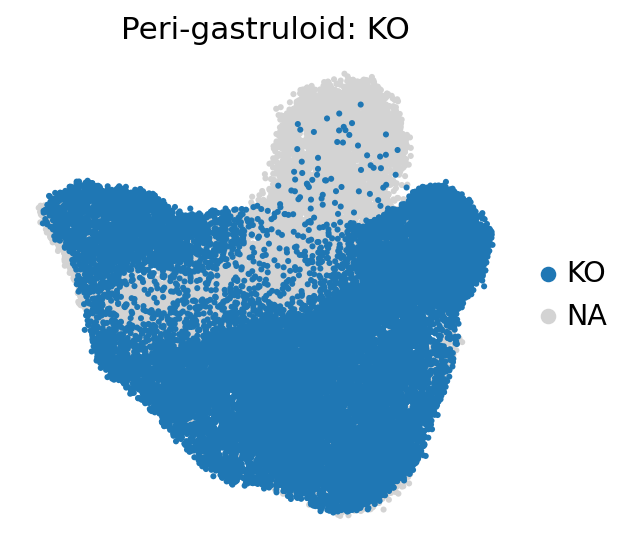

In [32]:
sc.pl.umap(adata, 
           color='group', 
           groups=['WT'], 
           title='Peri-gastruloid: WT',
           frameon=False, 
           size=30,
           na_color='lightgray') 

sc.pl.umap(adata, 
           color='group', 
           groups=['KO'], 
           title='Peri-gastruloid: KO',
           frameon=False, 
           size=30,
           na_color='lightgray')

In [61]:
adata_wt = adata[adata.obs['group'].isin(['WT'])]

/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list
/mnt/yiming/nfs_share/anaconda3/envs/scvi-env/lib/python3.9/site-packages/scanpy/plotting/_utils.py:487: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


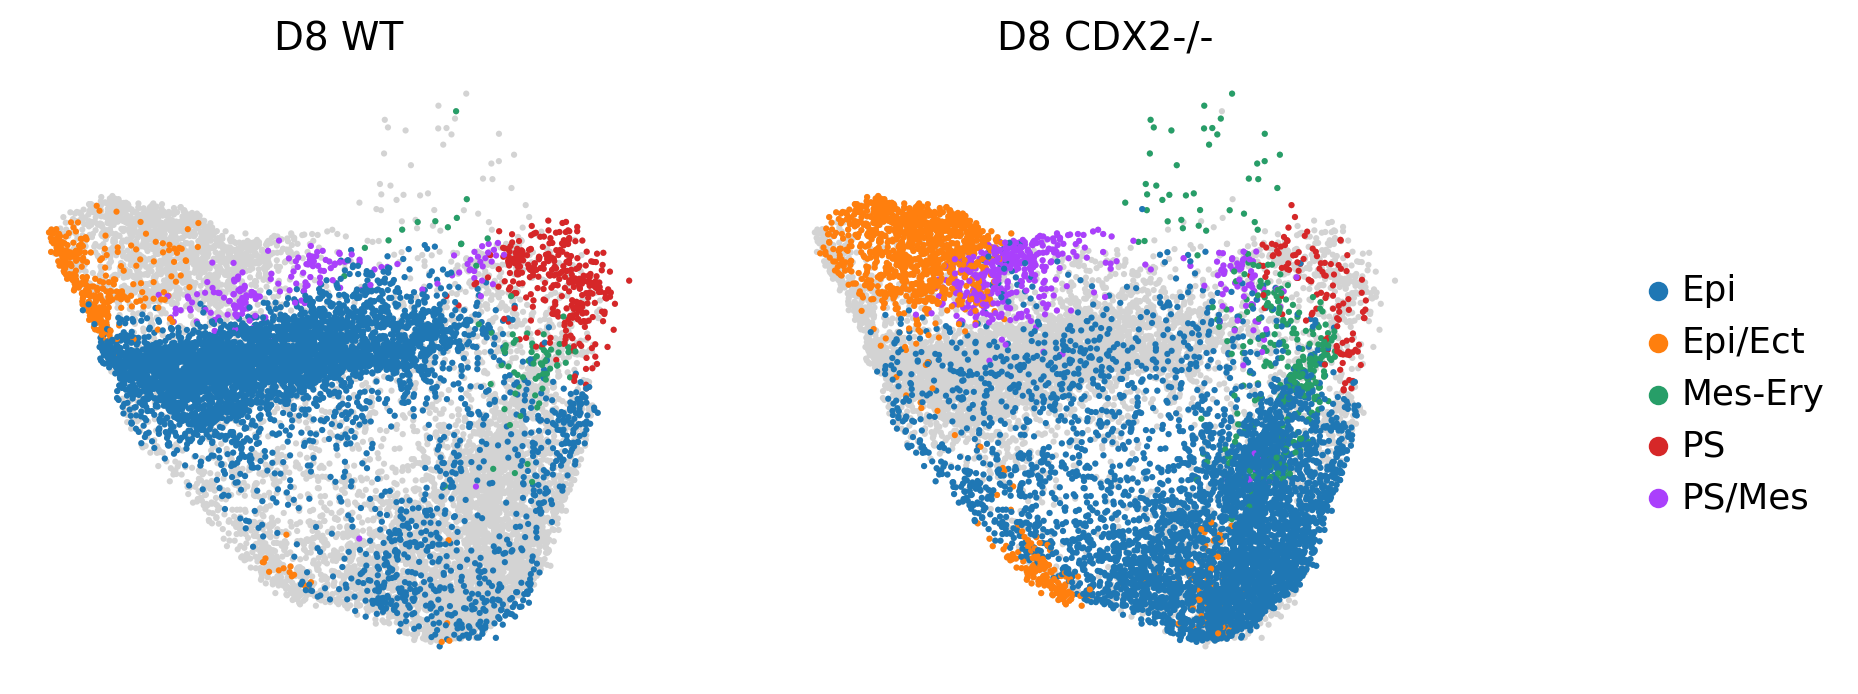

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# plot
num = list(np.arange(0, 2, 1))
sample_order = ['WT', 'KO']
sample_dict = dict(zip(num, sample_order))

fig, axs = plt.subplots(1, 2, figsize=(9, 4), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})
axs = axs.flatten()

legend_handles = []
legend_labels = []

display_titles = ['D8 WT', 'D8 CDX2-/-']

for i in sample_dict:
    sc.pl.umap(adata_d8, size=20, show=False, ax=axs[i], return_fig=fig)
    sc.pl.umap(adata_d8[adata_d8.obs['group'] == sample_order[i]], color='CellType_man', size=20, 
               show=False, return_fig=fig, ax=axs[i], title=display_titles[i], frameon=False)

    handles, labels = axs[i].get_legend_handles_labels()

    for handle, label in zip(handles, labels):
        if label not in legend_labels:
            legend_handles.append(handle)
            legend_labels.append(label)

    # Removing individual legends from each subplot
    axs[i].get_legend().remove()

sorted_legend_labels, sorted_legend_handles = zip(*sorted(zip(legend_labels, legend_handles)))

fig.legend(sorted_legend_handles, sorted_legend_labels, loc='center right', bbox_to_anchor=(1.2, 0.5), 
           ncol=1, frameon=False)


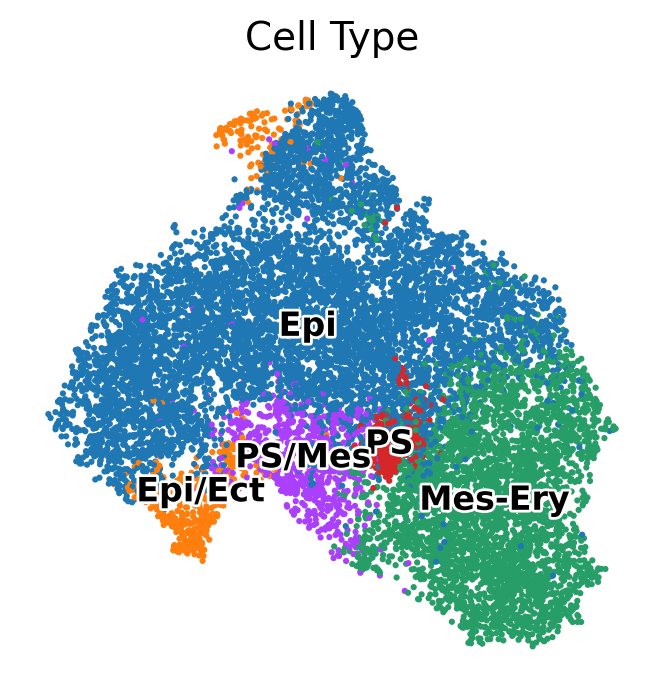

In [32]:
sc.pl.umap(adata_wt, color=['CellType_man'], frameon=False, legend_loc='on data', 
           legend_fontsize=12, legend_fontoutline=2, title='Cell Type', 
           size=20)

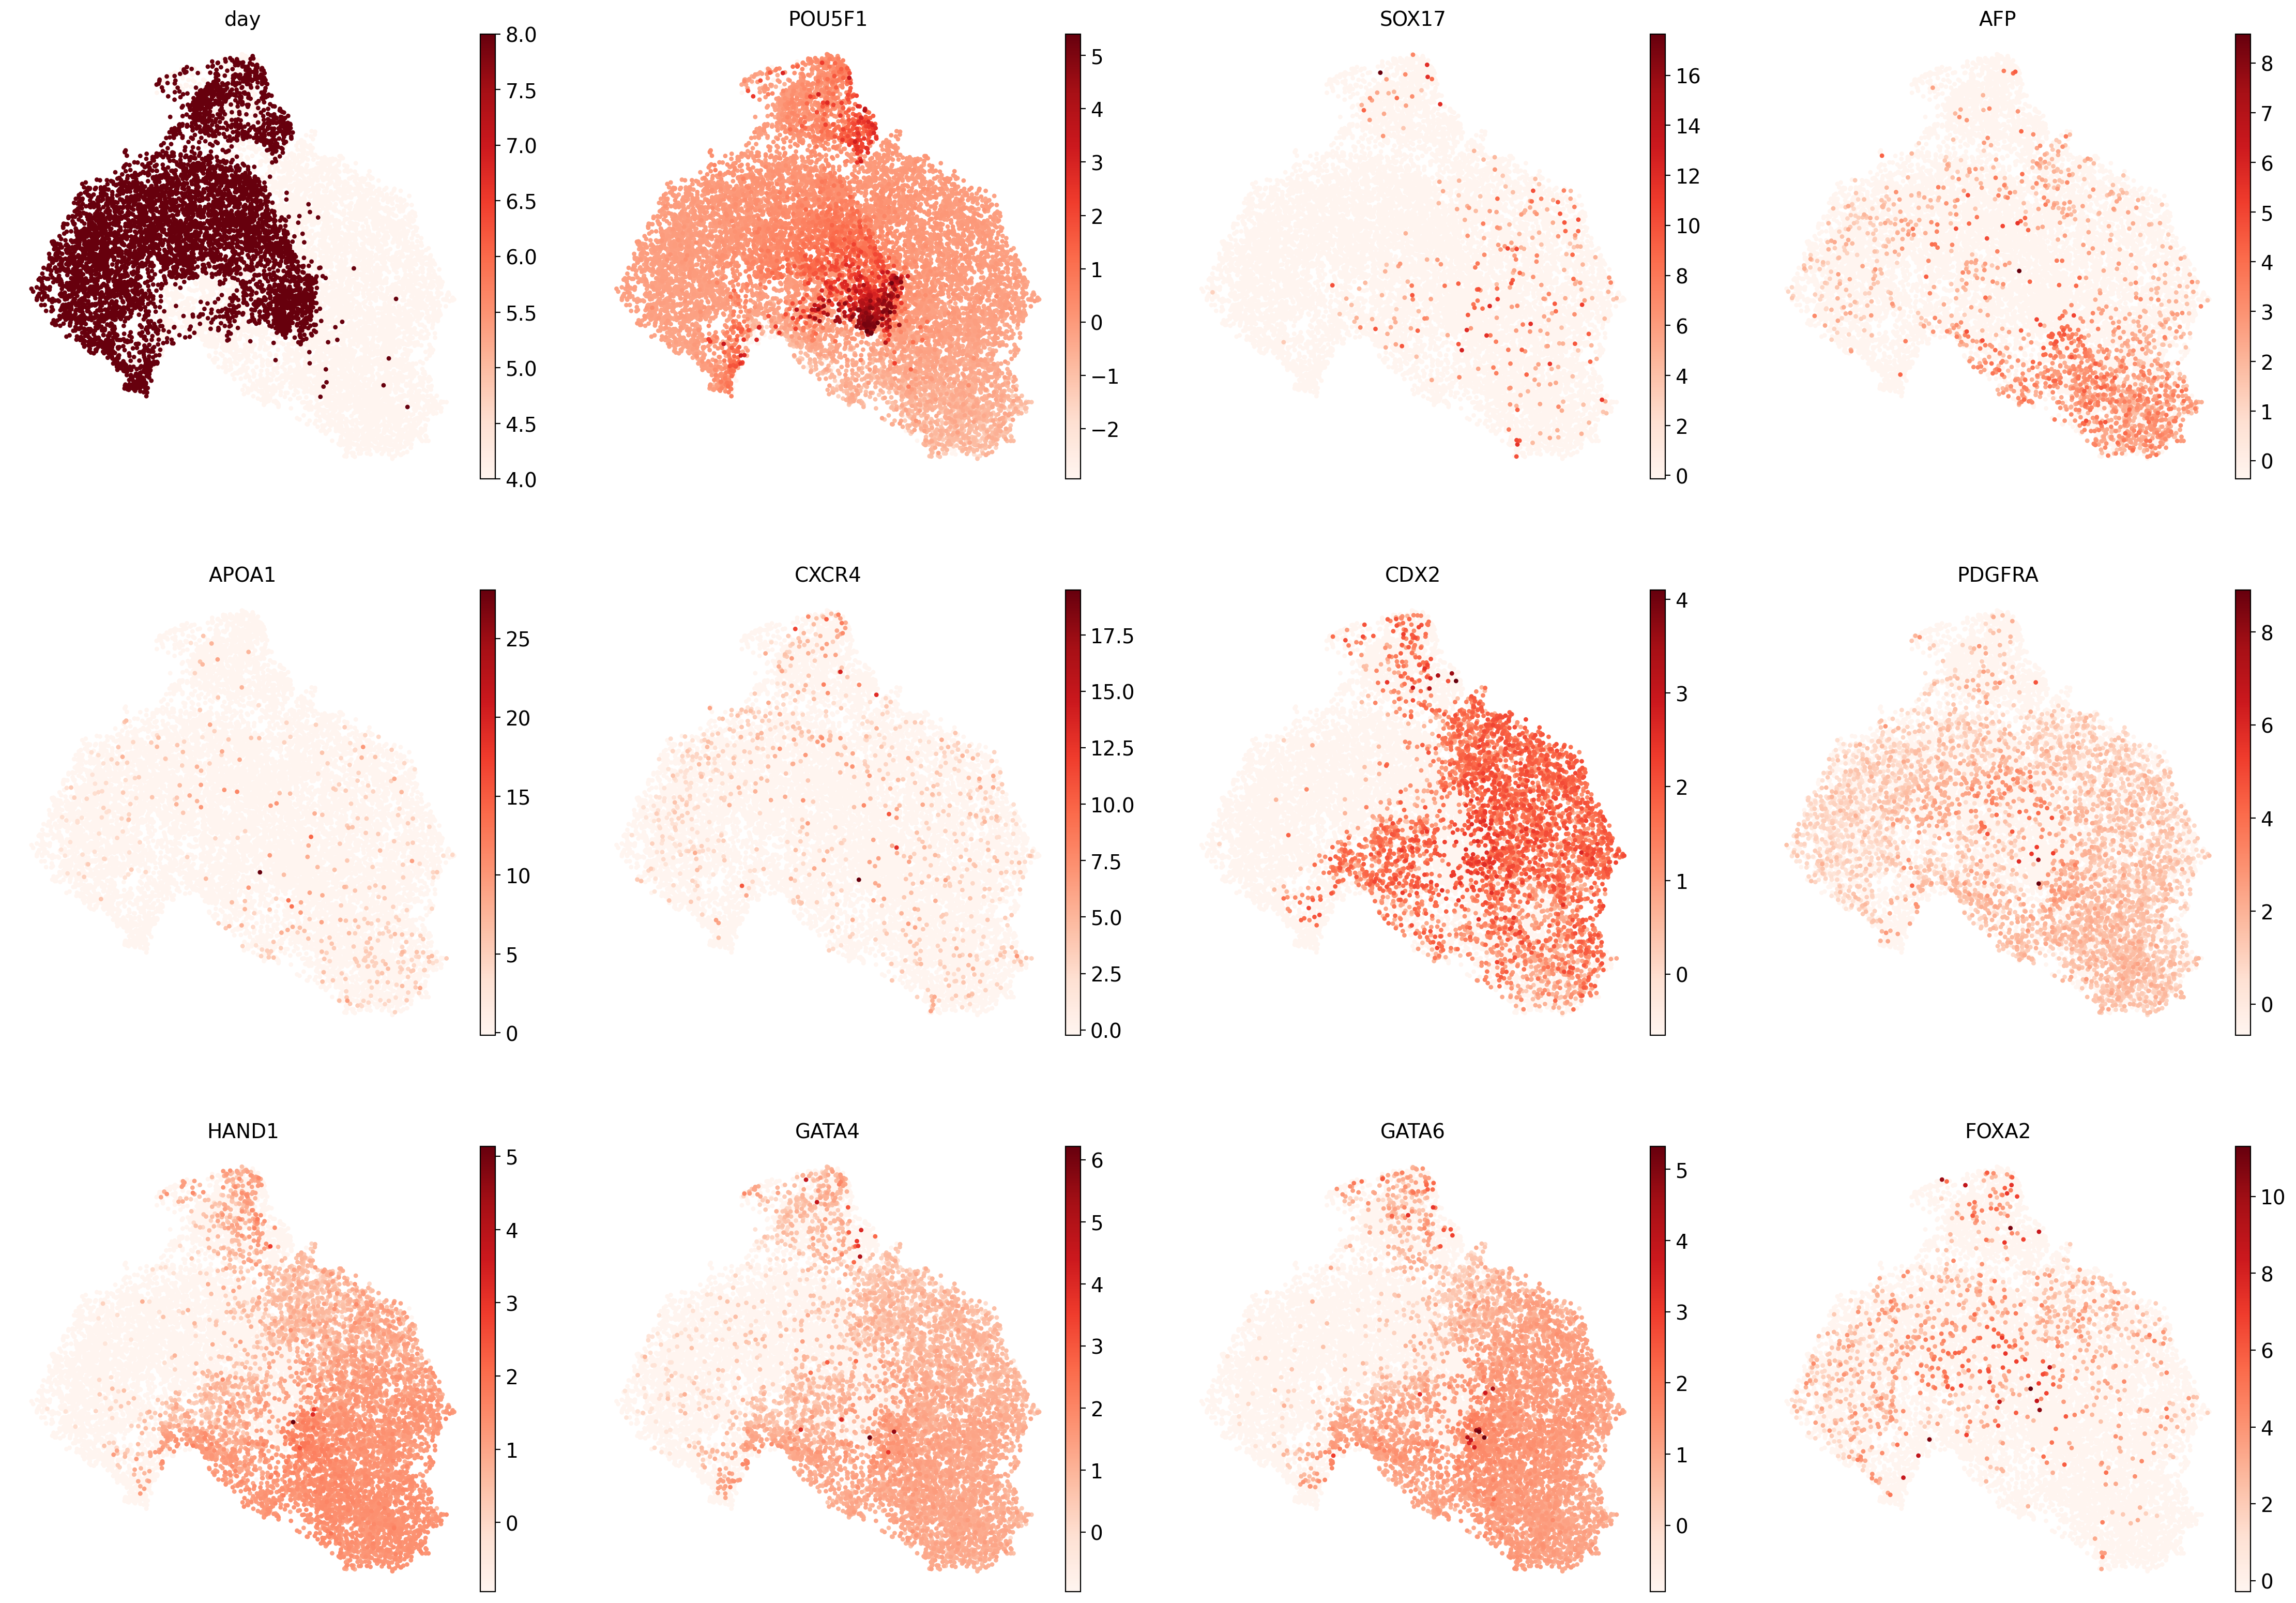

In [3]:
sc.pl.umap(adata_wt, color=['day', 'POU5F1', 'SOX17', 'AFP', 'APOA1', 'CXCR4', 
                             'CDX2', 'PDGFRA', 'HAND1', 
                         'GATA4', 'GATA6', 'FOXA2'], 
           frameon=False, size=40)

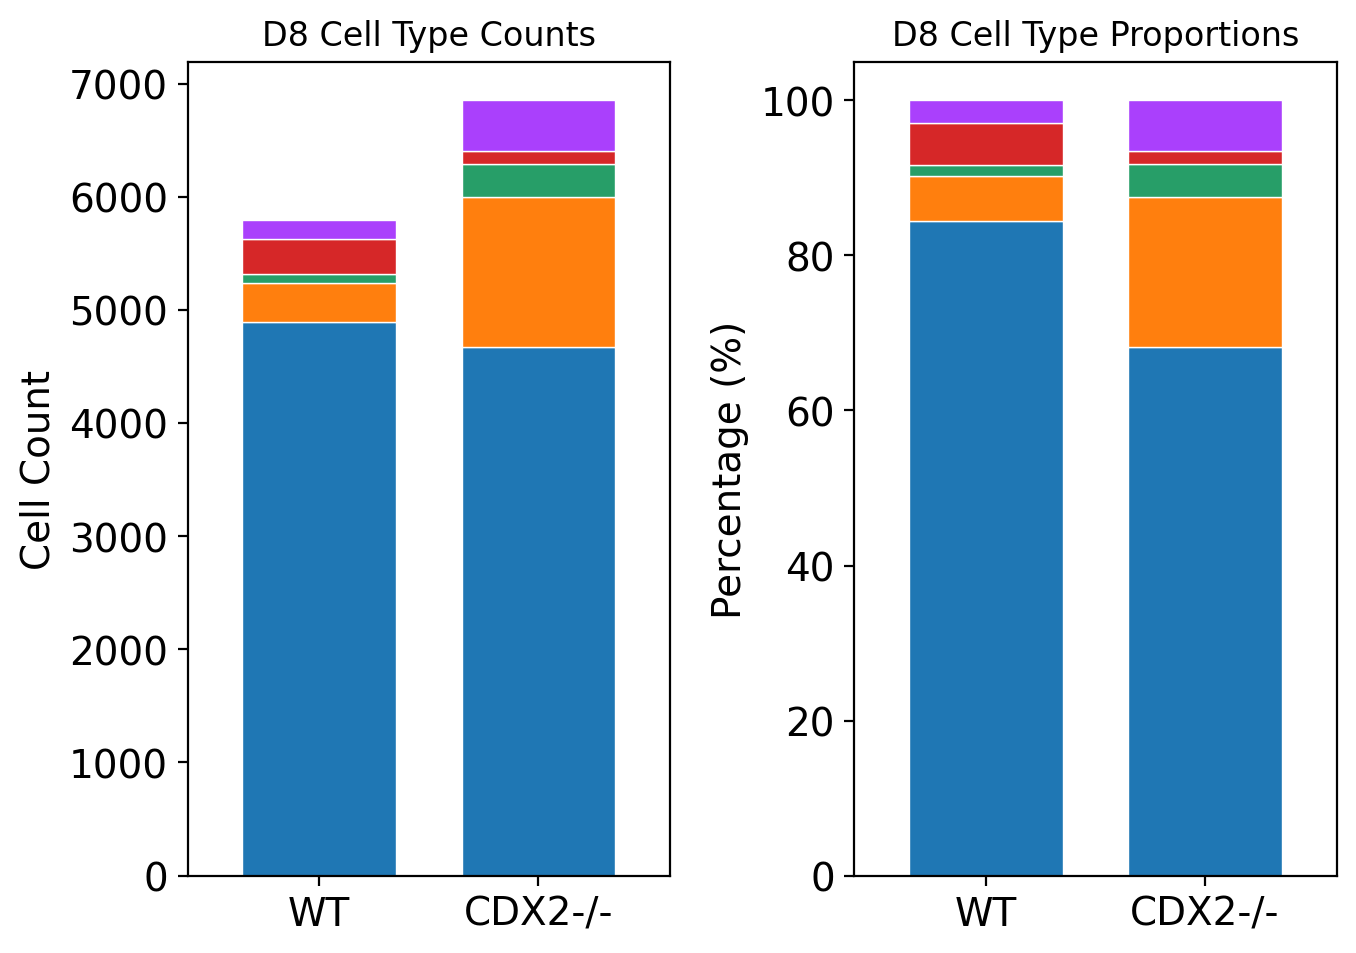

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

celltype_counts = pd.crosstab(adata_d8.obs['group'], adata.obs['CellType_man'])
celltype_counts = celltype_counts.reindex(['WT', 'KO'])
celltype_counts.index = ['WT', 'CDX2-/-']

celltype_props = celltype_counts.div(celltype_counts.sum(axis=1), axis=0) * 100

colors = adata.uns['CellType_man_colors']

fig, axes = plt.subplots(1, 2, figsize=(7, 5), gridspec_kw={'width_ratios': [1, 1]})

celltype_counts.plot(kind='bar', stacked=True, ax=axes[0], 
                     color=colors, legend=False, width=0.7, edgecolor='white', linewidth=0.5)
axes[0].set_title('D8 Cell Type Counts', fontsize=12)
axes[0].set_ylabel('Cell Count')

celltype_props.plot(kind='bar', stacked=True, ax=axes[1], 
                    color=colors, legend=False, width=0.7, edgecolor='white', linewidth=0.5)
axes[1].set_title('D8 Cell Type Proportions', fontsize=12)
axes[1].set_ylabel('Percentage (%)')

for ax in axes:
    ax.grid(False)               
    ax.set_facecolor('none')     
    ax.set_xlabel('')            
    ax.tick_params(axis='x', rotation=0) 
    
    # ax.spines['top'].set_visible(False)
    # ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()